[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SergioPascualRedondo/Proyect_SP_AI_FOR_MEDICINE/blob/main/notebooks/heart_disease_clinical_stages.ipynb)


# How Early Can Heart Disease Be Predicted? A Staged Machine Learning Analysis of the Cleveland UCI Dataset

**Sergio Pascual Redondo**  
**ERASMUS**

This project studies the Cleveland Heart Disease dataset as a binary classification problem, but the central question is staged: how much useful predictive performance can be obtained before all diagnostic variables are available?

The variables are organised into four clinically motivated stages, from routine information to advanced diagnostic tests. The models are trained and evaluated with a leakage-safe pipeline, nested cross-validation, and a final held-out test set.


## Project Workflow

The notebook follows the same order as the project: understand the clinical problem, inspect the dataset, define clinically meaningful feature stages, build a leakage-safe pipeline, validate the models, and compare the final results by stage.


# 1. Clinical Problem and Dataset

Heart disease is a major clinical problem where early identification can support triage and prioritisation for further testing. In practice, not all information is available at the same time: routine risk factors are usually available earlier, while exercise-test and advanced diagnostic variables may require more time, resources, or specialist assessment.

For this reason, this project is not framed only as a binary classifier. The main question is whether useful prediction is possible before all diagnostic information is available.


## Clinical Motivation

The staged design compares how performance changes when progressively more clinical information is added. This allows the model to be interpreted as a possible support tool for early screening and diagnostic prioritisation, not as an automatic diagnosis system.


# 2. Initial Setup

The notebook is prepared to run in Google Colab from the GitHub repository. The first cells clone the repository, install the required packages, import the libraries, and create the output folders used to save figures and tables.


In [ ]:
# Google Colab setup
import os
import sys
import subprocess
import importlib.util
import warnings
from pathlib import Path

REPO_URL = "https://github.com/SergioPascualRedondo/Proyect_SP_AI_FOR_MEDICINE.git"
PROJECT_ROOT = Path("/content/Proyect_SP_AI_FOR_MEDICINE")

subprocess.run(["git", "clone", REPO_URL, str(PROJECT_ROOT)], check=False)
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


In [ ]:
# Install the exact project dependencies in Google Colab
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])


In [3]:
# Output folders
FIG_EDA = PROJECT_ROOT / "results" / "figures" / "eda"
FIG_CV = PROJECT_ROOT / "results" / "figures" / "cv"
FIG_TEST = PROJECT_ROOT / "results" / "figures" / "final_test"
FIG_TEST_CONFUSION = FIG_TEST / "confusion_matrices_by_stage"
FIG_TEST_ROC = FIG_TEST / "roc_by_stage"
FIG_EXPLAIN = PROJECT_ROOT / "results" / "figures" / "explainability"

TAB_EDA = PROJECT_ROOT / "results" / "tables" / "eda"
TAB_CV = PROJECT_ROOT / "results" / "tables" / "cv"
TAB_TEST = PROJECT_ROOT / "results" / "tables" / "final_test"
TAB_EXPLAIN = PROJECT_ROOT / "results" / "tables" / "explainability"

for folder in [FIG_EDA, FIG_CV, FIG_TEST, FIG_TEST_CONFUSION, FIG_TEST_ROC, FIG_EXPLAIN, TAB_EDA, TAB_CV, TAB_TEST, TAB_EXPLAIN]:
    folder.mkdir(parents=True, exist_ok=True)


# 3. Data Loading, Quality Control and EDA

The project uses the cleaned Cleveland Heart Disease CSV. The target variable is binary: `condition = 0` means absence of heart disease, and `condition = 1` means presence of heart disease.


In [4]:
df = load_heart_data()
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [5]:
print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Dataset shape: (297, 14)
Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']


## Variable Meaning

The dataset contains tabular clinical variables. Some are continuous measurements, some are binary variables, and others are categorical clinical findings that need to be encoded inside the pipeline.


## Data Quality Control

Before modelling, the dataset is checked for missing values, duplicated rows, unexpected question-mark values, class balance, and basic clinical plausibility.


In [6]:
report = data_quality_report(df)

print("Rows:", report["n_rows"])
print("Columns:", report["n_columns"])
print("Duplicated rows:", report["duplicated_rows"])
print("\nMissing values per column:")
print(report["missing_values"])
print("\nQuestion mark values per column:")
print(report["question_mark_values"])
print("\nTarget counts:")
print(report["target_counts"])

Rows: 297
Columns: 14
Duplicated rows: 0

Missing values per column:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

Question mark values per column:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

Target counts:
condition
0    160
1    137
Name: count, dtype: int64


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0
sex,297.0,0.676768,0.468500,0.0,0.0,1.0,1.0,1.0
cp,297.0,2.158249,0.964859,0.0,2.0,2.0,3.0,3.0
trestbps,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0
fbs,297.0,0.144781,0.352474,0.0,0.0,0.0,0.0,1.0
restecg,297.0,0.996633,0.994914,0.0,0.0,1.0,2.0,2.0
thalach,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0
exang,297.0,0.326599,0.469761,0.0,0.0,0.0,1.0,1.0
oldpeak,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2


## Data Quality Interpretation

The local file is already clean: no missing values, no duplicated rows, and no `?` values were found. Therefore, the main challenge is not heavy cleaning, but correct preprocessing, validation, and clinical interpretation.


## Exploratory Data Analysis

The following plots compare patients with and without heart disease and help identify which variables may be clinically informative before training any model.


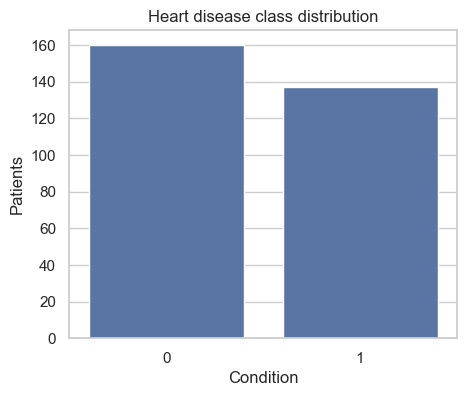

In [8]:
fig, ax = plot_target_distribution(df)
plt.show()

In [9]:
print((df[TARGET].value_counts(normalize=True).sort_index() * 100).round(2))

condition
0    53.87
1    46.13
Name: proportion, dtype: float64


The target is reasonably balanced. Therefore, the project can focus on clinical staging, validation, and threshold behaviour rather than class-imbalance corrections.

## Visual Summary


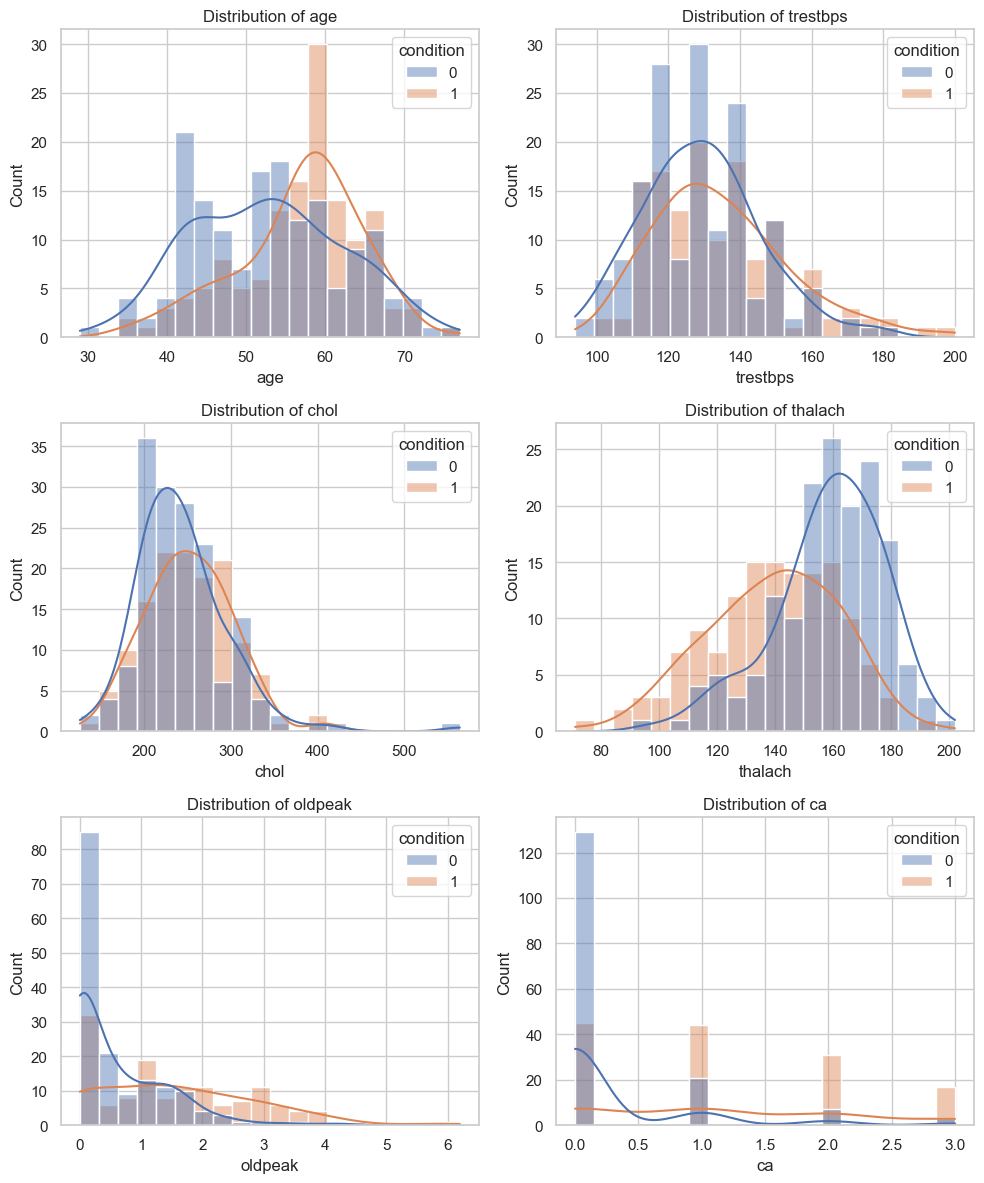

In [10]:
fig, axes = plot_numeric_histograms(df, ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"])
save_figure(fig, FIG_EDA / "numeric_distributions_by_condition.png")
plt.show()

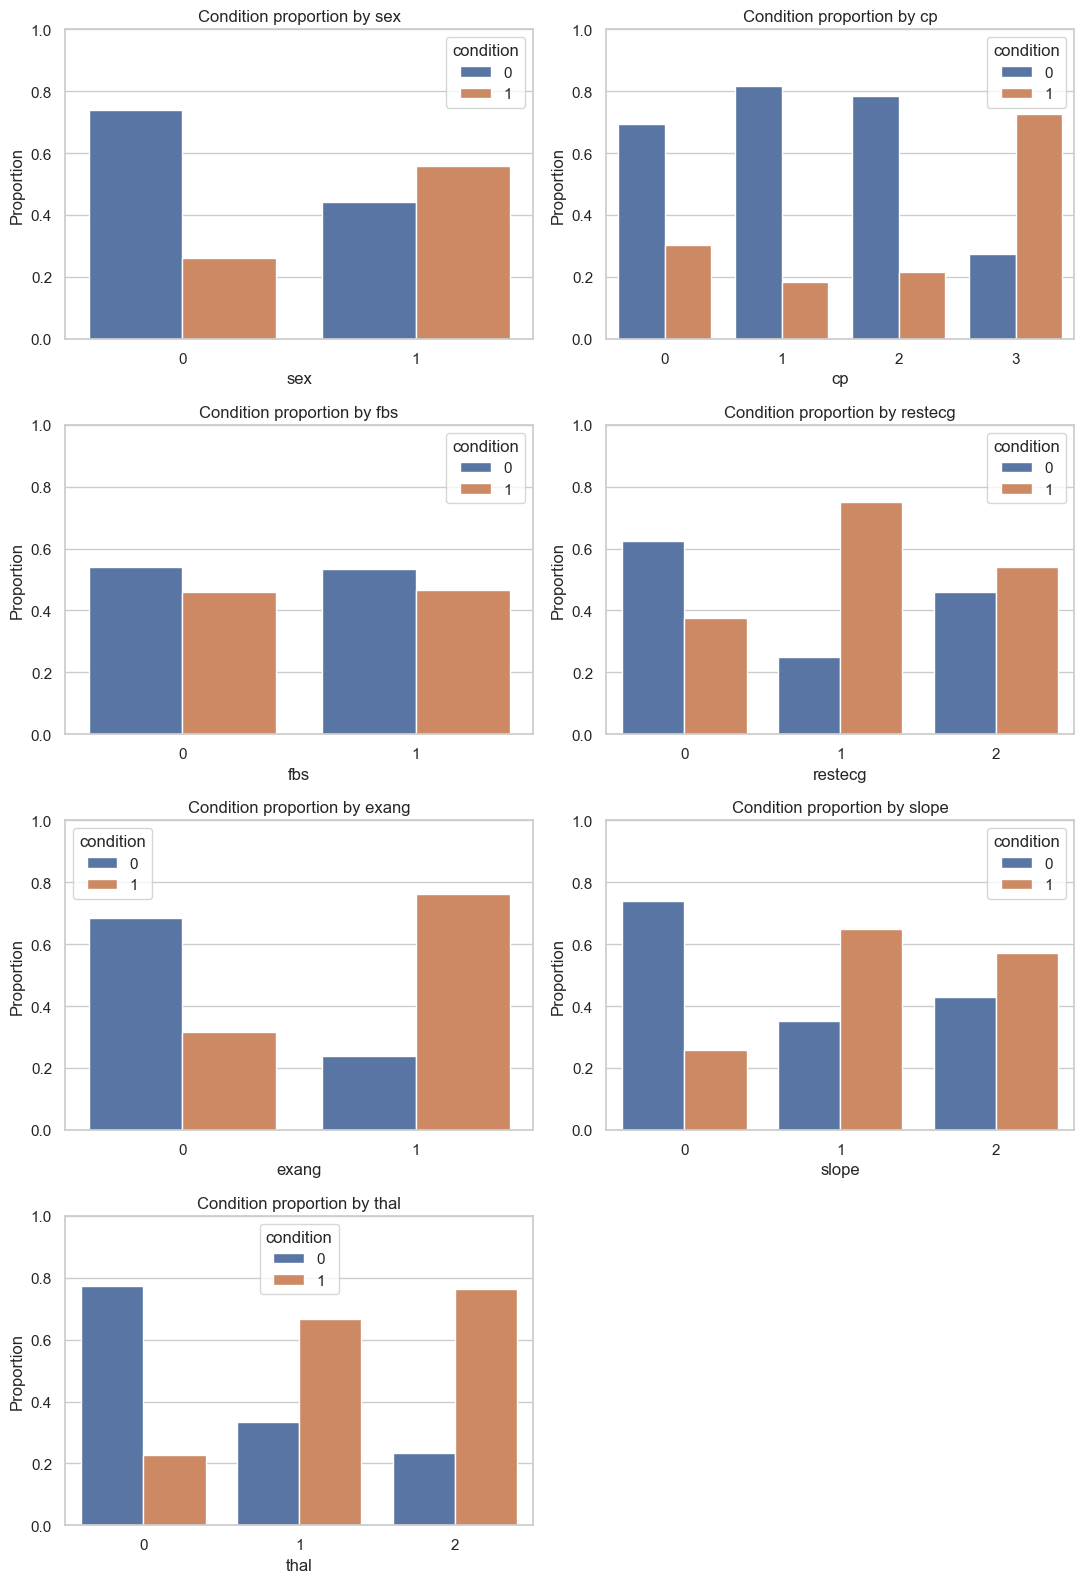

In [11]:
fig, axes = plot_categorical_proportions(df, ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"])
save_figure(fig, FIG_EDA / "categorical_proportions_by_condition.png")
plt.show()

## Numeric Variables


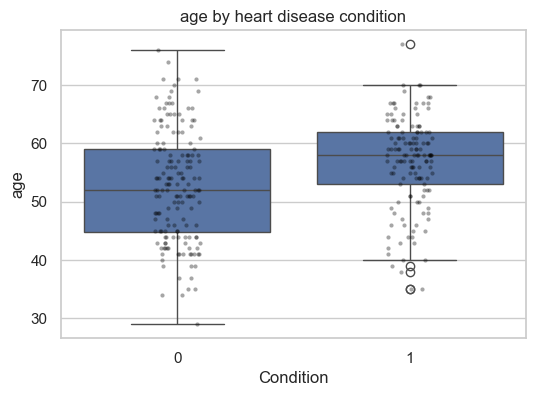

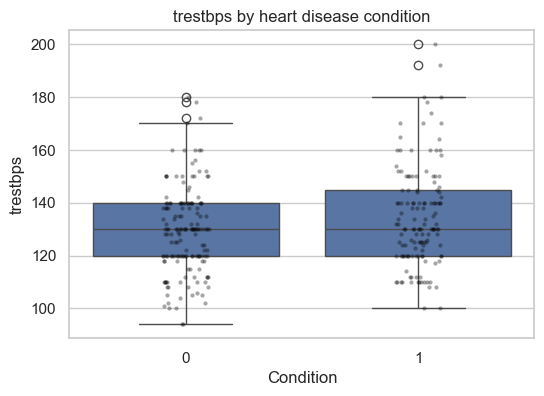

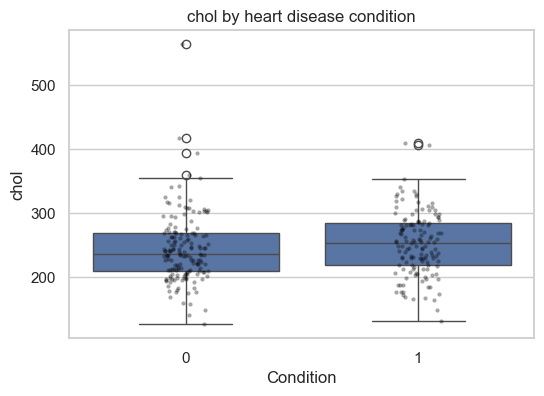

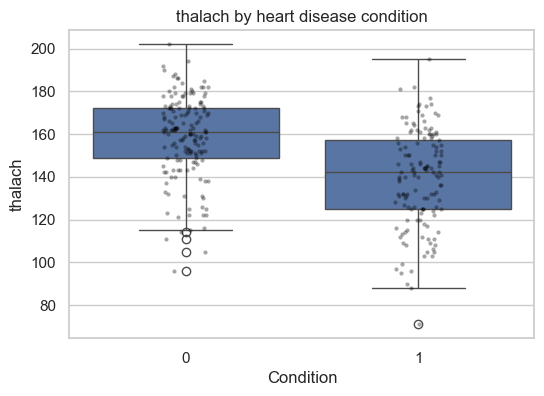

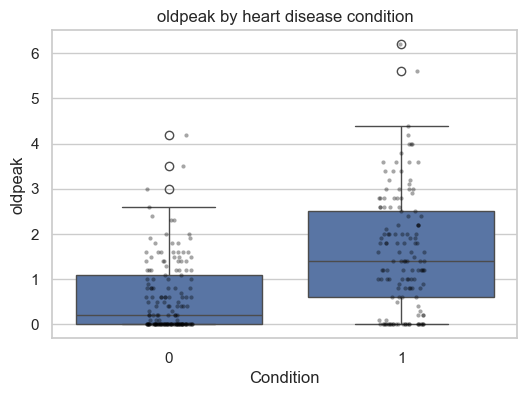

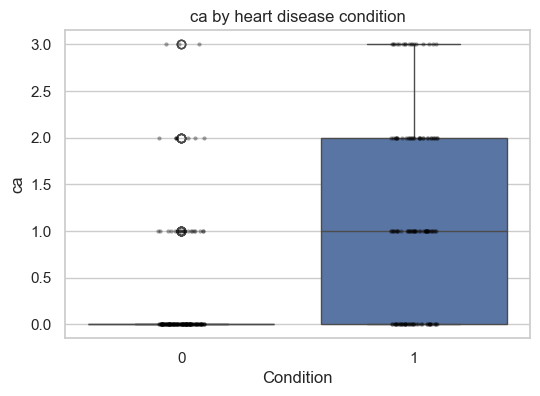

In [12]:
for column in ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]:
    fig, ax = plot_numeric_by_condition(df, column)
    plt.show()

## Categorical Variables


In [13]:
categorical_to_plot = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

for column in categorical_to_plot:
    table = pd.crosstab(df[column], df[TARGET], normalize="columns") * 100
    print("\n", column)
    display(table.round(1))


 sex


condition,0,1
sex,,
0,44.4,18.2
1,55.6,81.8



 cp


condition,0,1
cp,,
0,10.0,5.1
1,25.0,6.6
2,40.6,13.1
3,24.4,75.2



 fbs


condition,0,1
fbs,,
0,85.6,85.4
1,14.4,14.6



 restecg


condition,0,1
restecg,,
0,57.5,40.1
1,0.6,2.2
2,41.9,57.7



 exang


condition,0,1
exang,,
0,85.6,46.0
1,14.4,54.0



 slope


condition,0,1
slope,,
0,64.4,26.3
1,30.0,65.0
2,5.6,8.8



 thal


condition,0,1
thal,,
0,79.4,27.0
1,3.8,8.8
2,16.9,64.2


## Correlation Check


In [14]:
correlations = df.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
correlations.to_frame("correlation_with_condition")

,correlation_with_condition
thal,0.520516
ca,0.463189
oldpeak,0.424052
thalach,-0.423817
exang,0.421355
cp,0.408945
slope,0.333049
sex,0.278467
age,0.227075
restecg,0.166343


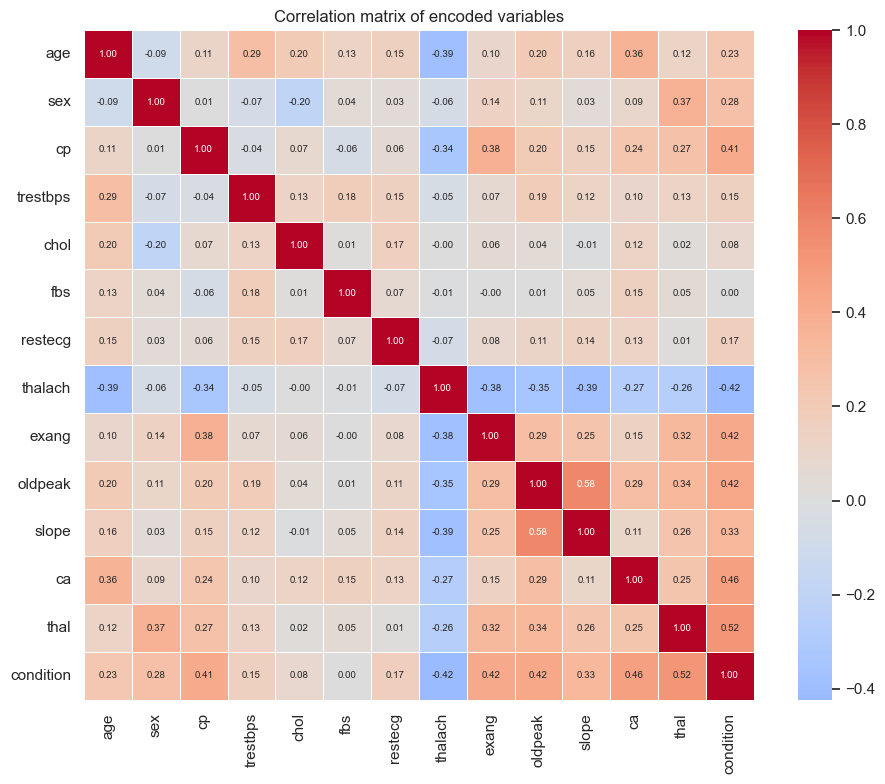

In [15]:
fig, ax = plot_correlation_heatmap(df)
save_figure(fig, FIG_EDA / "correlation_heatmap.png")
plt.show()

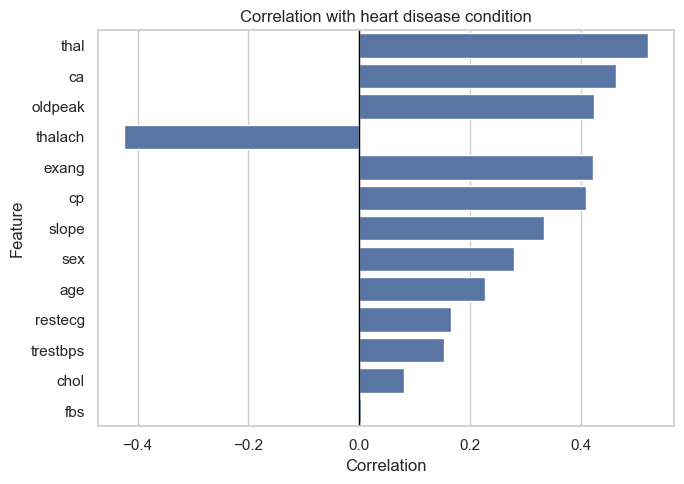

In [16]:
fig, ax = plot_target_correlations(df)
save_figure(fig, FIG_EDA / "target_correlations.png")
plt.show()

# 4. Clinical Feature Stages

The variables are organised into four incremental clinical stages according to when they could realistically become available in a diagnostic pathway.


In [17]:
for stage_name, features in STAGE_FEATURES.items():
    print(stage_name)
    print("Number of features:", len(features))
    print(features)
    print()

Stage 1 - Routine risk factors
Number of features: 5
['age', 'sex', 'trestbps', 'chol', 'fbs']

Stage 2 - Symptoms and resting ECG
Number of features: 7
['age', 'sex', 'trestbps', 'chol', 'fbs', 'cp', 'restecg']

Stage 3 - Exercise stress test
Number of features: 11
['age', 'sex', 'trestbps', 'chol', 'fbs', 'cp', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope']

Stage 4 - Advanced diagnostic tests
Number of features: 13
['age', 'sex', 'trestbps', 'chol', 'fbs', 'cp', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']



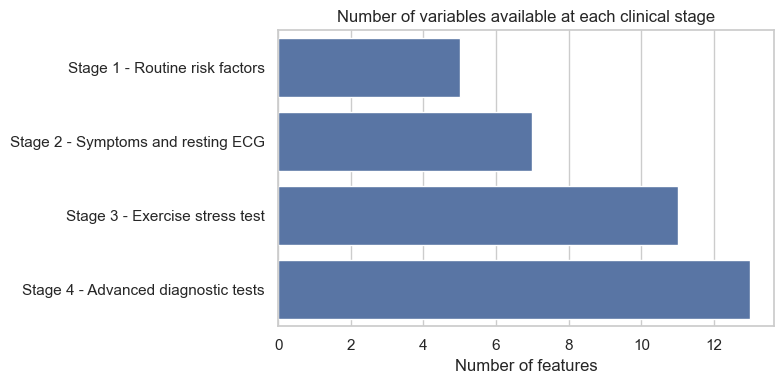

In [18]:
fig, ax = plot_stage_sizes(STAGE_FEATURES)
save_figure(fig, FIG_EDA / "clinical_stage_sizes.png")
plt.show()

| Stage | Features added | Clinical interpretation |
|---|---|---|
| Stage 1 | `age`, `sex`, `trestbps`, `chol`, `fbs` | Routine cardiovascular risk factors |
| Stage 2 | + `cp`, `restecg` | Symptoms and resting ECG |
| Stage 3 | + `thalach`, `exang`, `oldpeak`, `slope` | Exercise stress test information |
| Stage 4 | + `ca`, `thal` | More advanced diagnostic measurements |

The comparison across stages is the central experiment of the project.

# 5. Pipeline and Leakage Control

The pipeline is the central technical element of the project. It keeps preprocessing and modelling together, so transformations are fitted only on training data during cross-validation and final testing.


## One Pipeline Template


In [19]:
example_stage_name = "Stage 4 - Advanced diagnostic tests"
example_features = STAGE_FEATURES[example_stage_name]
example_model = candidate_models()["Logistic Regression"]["estimator"]

example_pipeline = build_pipeline(example_features, example_model)
example_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default

## Leakage Prevention and Audit

The pipeline protects mainly against L1 leakage, because imputing, scaling and one-hot encoding are fitted only inside the training folds.

The other leakage risks are handled by the study design: features are grouped by clinical availability to reduce L2 illegitimate-feature problems, and the split is performed at patient level to avoid non-independence between train and test samples.


# 6. Validation and Model Selection

The validation strategy uses a locked test set and nested cross-validation on the development set. This separates model selection from final evaluation.


In [20]:
train_df, test_df = make_locked_split(df, test_size=0.2)

print("Development set:", train_df.shape)
print("Locked test set:", test_df.shape)
print("\nDevelopment target distribution:")
print(train_df[TARGET].value_counts(normalize=True).sort_index().round(3))
print("\nLocked test target distribution:")
print(test_df[TARGET].value_counts(normalize=True).sort_index().round(3))

Development set: (237, 14)
Locked test set: (60, 14)

Development target distribution:
condition
0    0.54
1    0.46
Name: proportion, dtype: float64

Locked test target distribution:
condition
0    0.533
1    0.467
Name: proportion, dtype: float64


## Nested Cross-Validation

The outer loop estimates generalisation performance, while the inner loop selects hyperparameters with `GridSearchCV`. ROC-AUC is used as the main selection metric because it evaluates discrimination across thresholds.


## Candidate Models

Logistic Regression is the primary model because it is simple and interpretable for a small tabular medical dataset. Random Forest is included as a secondary comparator for possible nonlinear relationships.


In [21]:
models = candidate_models()

for model_name, model_spec in models.items():
    print(model_name)
    print(model_spec["param_grid"])
    print()

Logistic Regression
{'clf__C': [0.01, 0.1, 1, 10], 'clf__solver': ['liblinear']}

Random Forest
{'clf__n_estimators': [100], 'clf__max_depth': [None, 5], 'clf__min_samples_leaf': [1, 5]}



## Nested CV Experiment

The experiment compares both models across the four clinical stages using the same validation strategy.


In [22]:
N_REPEATS = 5
all_results = []

for stage_name, stage_features in STAGE_FEATURES.items():
    for model_name, model_spec in models.items():
        print(f"Running: {stage_name} | {model_name}")
        stage_results = nested_cv_stage(
            train_df=train_df,
            stage_name=stage_name,
            stage_features=stage_features,
            model_name=model_name,
            model_spec=model_spec,
            n_repeats=N_REPEATS,
        )
        all_results.append(stage_results)

cv_results = pd.concat(all_results, ignore_index=True)
cv_results.head()

Running: Stage 1 - Routine risk factors | Logistic Regression


Running: Stage 1 - Routine risk factors | Random Forest


Running: Stage 2 - Symptoms and resting ECG | Logistic Regression


Running: Stage 2 - Symptoms and resting ECG | Random Forest


Running: Stage 3 - Exercise stress test | Logistic Regression


Running: Stage 3 - Exercise stress test | Random Forest


Running: Stage 4 - Advanced diagnostic tests | Logistic Regression


Running: Stage 4 - Advanced diagnostic tests | Random Forest


,stage,model,fold,roc_auc,accuracy,balanced_accuracy
0,Stage 1 - Routine risk factors,Logistic Regression,0,0.690559,0.666667,0.664336
1,Stage 1 - Routine risk factors,Logistic Regression,1,0.590909,0.541667,0.545455
2,Stage 1 - Routine risk factors,Logistic Regression,2,0.547273,0.595745,0.587273
3,Stage 1 - Routine risk factors,Logistic Regression,3,0.785455,0.702128,0.692727
4,Stage 1 - Routine risk factors,Logistic Regression,4,0.609890,0.617021,0.612637


In [23]:
cv_summary = (
    cv_results
    .groupby(["stage", "model"])[["roc_auc", "accuracy", "balanced_accuracy"]]
    .agg(["mean", "std"])
)
cv_summary.to_csv(TAB_CV / "nested_cv_summary.csv")
cv_summary

roc_auc            \
                                                             mean       std   
stage                               model                                     
Stage 1 - Routine risk factors      Logistic Regression  0.657894  0.076373   
                                    Random Forest        0.691649  0.061427   
Stage 2 - Symptoms and resting ECG  Logistic Regression  0.805605  0.066871   
                                    Random Forest        0.800810  0.065860   
Stage 3 - Exercise stress test      Logistic Regression  0.846634  0.051448   
                                    Random Forest        0.851030  0.054181   
Stage 4 - Advanced diagnostic tests Logistic Regression  0.890444  0.048483   
                                    Random Forest        0.889033  0.052093   

                                                         accuracy            \
                                                             mean       std   
stage                               model                                     
Stage 1 - Routine risk factors      Logistic Regression  0.619450  0.053617   
                                    Random Forest        0.654007  0.064797   
Stage 2 - Symptoms and resting ECG  Logistic Regression  0.745337  0.057639   
                                    Random Forest        0.733564  0.058514   
Stage 3 - Exercise stress test      Logistic Regression  0.770603  0.044789   
                                    Random Forest        0.746188  0.051577   
Stage 4 - Advanced diagnostic tests Logistic Regression  0.826277  0.059465   
                                    Random Forest        0.817784  0.066174   

                                                        balanced_accuracy  \
                                                                     mean   
stage                               model                                   
Stage 1 - Routine risk factors      Logistic Regression          0.616263   
                                    Random Forest                0.652243   
Stage 2 - Symptoms and resting ECG  Logistic Regression          0.745245   
                                    Random Forest                0.732484   
Stage 3 - Exercise stress test      Logistic Regression          0.768111   
                                    Random Forest                0.742481   
Stage 4 - Advanced diagnostic tests Logistic Regression          0.821399   
                                    Random Forest                0.814431   

                                                                   
                                                              std  
stage                               model                          
Stage 1 - Routine risk factors      Logistic Regression  0.052941  
                                    Random Forest        0.064439  
Stage 2 - Symptoms and resting ECG  Logistic Regression  0.058921  
                                    Random Forest        0.058549  
Stage 3 - Exercise stress test      Logistic Regression  0.044272  
                                    Random Forest        0.053603  
Stage 4 - Advanced diagnostic tests Logistic Regression  0.060517  
                                    Random Forest        0.068217

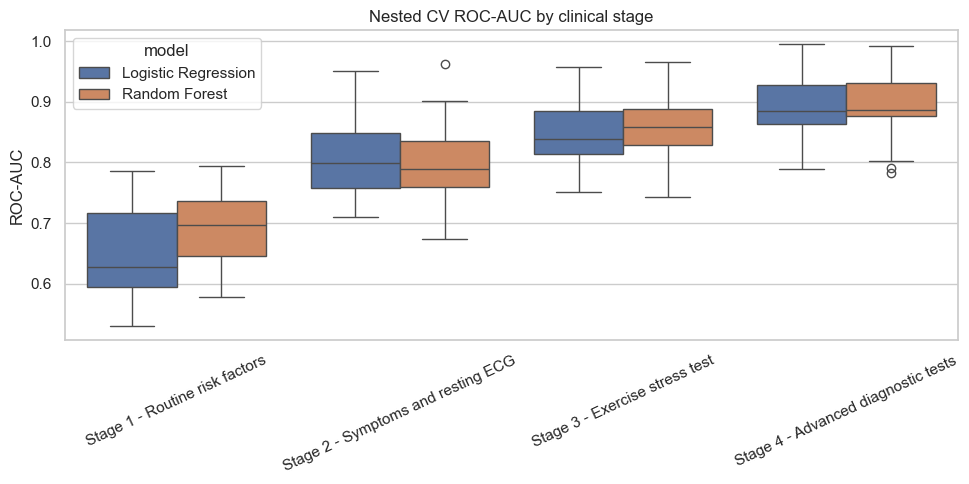

In [24]:
fig, ax = plot_cv_auc_by_stage(cv_results)
save_figure(fig, FIG_CV / "nested_cv_auc_boxplot_by_stage.png")
plt.show()

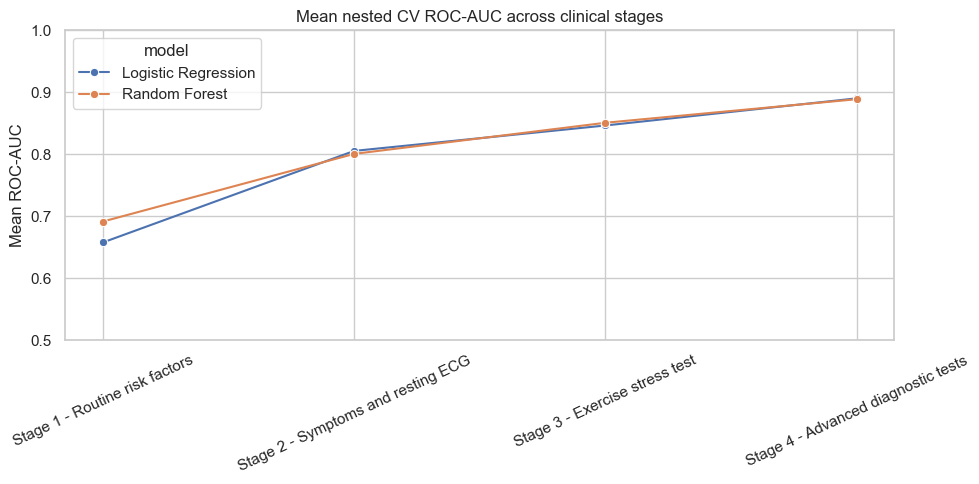

In [25]:
fig, ax = plot_cv_auc_lines(cv_results)
save_figure(fig, FIG_CV / "nested_cv_auc_line_by_stage.png")
plt.show()

## Cross-Validation Interpretation

The main result is the progressive improvement across clinical stages, especially when symptoms/resting ECG and later diagnostic variables are added.


## Final Strategy Selection

The final strategy is selected from development-set results before looking at the locked test set.


In [26]:
mean_auc = (
    cv_results
    .groupby(["stage", "model"], as_index=False)["roc_auc"]
    .mean()
    .sort_values("roc_auc", ascending=False)
)
mean_auc

,stage,model,roc_auc
6,Stage 4 - Advanced diagnostic tests,Logistic Regression,0.890444
7,Stage 4 - Advanced diagnostic tests,Random Forest,0.889033
5,Stage 3 - Exercise stress test,Random Forest,0.851030
4,Stage 3 - Exercise stress test,Logistic Regression,0.846634
2,Stage 2 - Symptoms and resting ECG,Logistic Regression,0.805605
3,Stage 2 - Symptoms and resting ECG,Random Forest,0.800810
1,Stage 1 - Routine risk factors,Random Forest,0.691649
0,Stage 1 - Routine risk factors,Logistic Regression,0.657894


In [27]:
best_row = mean_auc.iloc[0]
selected_stage = best_row["stage"]
selected_model = best_row["model"]
selected_features = STAGE_FEATURES[selected_stage]
selected_spec = models[selected_model]

print("Selected stage:", selected_stage)
print("Selected model:", selected_model)
print("Development ROC-AUC:", round(best_row["roc_auc"], 3))

Selected stage: Stage 4 - Advanced diagnostic tests
Selected model: Logistic Regression
Development ROC-AUC: 0.89


# 7. Final Evaluation, Stage Comparison and Interpretation

After model selection, thresholds are inspected using development predictions and the locked test set is used for the final evaluation. The final comparison by stage directly answers the clinical question of the project.

For the stage comparison, the threshold is selected only on development predictions by maximising balanced accuracy and then sensitivity. This keeps the locked test set untouched until the final estimate. ROC-AUC confidence intervals are estimated with bootstrap resampling because the test set is small. Brier score is reported as a simple check of probability calibration.


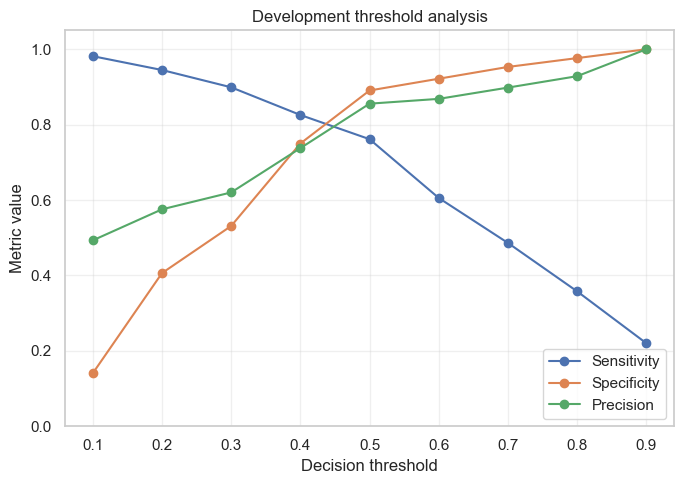

,threshold,sensitivity,specificity,precision,accuracy,balanced_accuracy
0,0.1,0.981651,0.140625,0.493088,0.527426,0.561138
1,0.2,0.944954,0.406250,0.575419,0.654008,0.675602
2,0.3,0.899083,0.531250,0.620253,0.700422,0.715166
3,0.4,0.825688,0.750000,0.737705,0.784810,0.787844
4,0.5,0.761468,0.890625,0.855670,0.831224,0.826046
5,0.6,0.605505,0.921875,0.868421,0.776371,0.763690
6,0.7,0.486239,0.953125,0.898305,0.738397,0.719682
7,0.8,0.357798,0.976562,0.928571,0.691983,0.667180
8,0.9,0.220183,1.000000,1.000000,0.641350,0.610092


In [28]:
threshold_grid = np.round(np.arange(0.1, 1.0, 0.1), 2)
selected_eval = evaluate_selected_strategy(
    train_df, test_df, selected_features, selected_spec,
    build_pipeline, split_features_target, SEED,
    threshold_grid=threshold_grid,
    report_threshold=0.5,
)

fig, ax = save_threshold_analysis(
    selected_eval["dev_threshold_table"],
    table_path=TAB_CV / "development_threshold_metrics.csv",
    figure_path=FIG_CV / "development_threshold_tradeoff.png",
    title="Development threshold analysis",
)
plt.show()

selected_eval["dev_threshold_table"][["threshold", "sensitivity", "specificity", "precision", "accuracy", "balanced_accuracy"]]


## Final Test Evaluation


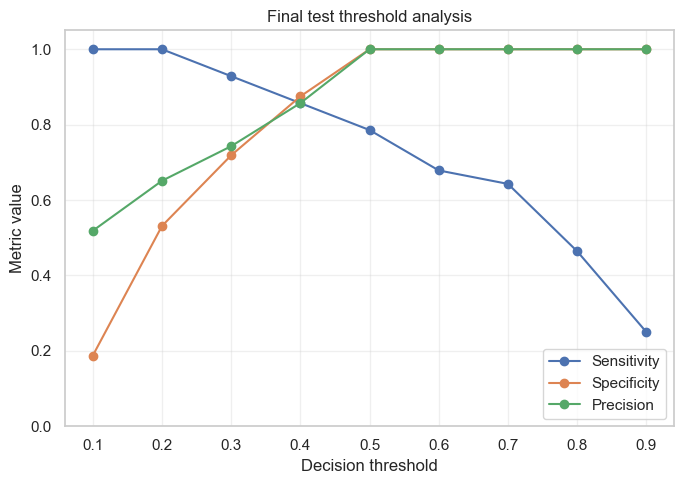

,threshold,roc_auc,roc_auc_ci_low,roc_auc_ci_high,sensitivity,specificity,precision,accuracy,balanced_accuracy,brier_score,tn,fp,fn,tp
0,0.1,0.955357,0.900438,0.993326,1.000000,0.18750,0.518519,0.566667,0.593750,0.098049,6,26,0,28
1,0.2,0.955357,0.900438,0.993326,1.000000,0.53125,0.651163,0.750000,0.765625,0.098049,17,15,0,28
2,0.3,0.955357,0.900438,0.993326,0.928571,0.71875,0.742857,0.816667,0.823661,0.098049,23,9,2,26
3,0.4,0.955357,0.900438,0.993326,0.857143,0.87500,0.857143,0.866667,0.866071,0.098049,28,4,4,24
4,0.5,0.955357,0.900438,0.993326,0.785714,1.00000,1.000000,0.900000,0.892857,0.098049,32,0,6,22
5,0.6,0.955357,0.900438,0.993326,0.678571,1.00000,1.000000,0.850000,0.839286,0.098049,32,0,9,19
6,0.7,0.955357,0.900438,0.993326,0.642857,1.00000,1.000000,0.833333,0.821429,0.098049,32,0,10,18
7,0.8,0.955357,0.900438,0.993326,0.464286,1.00000,1.000000,0.750000,0.732143,0.098049,32,0,15,13
8,0.9,0.955357,0.900438,0.993326,0.250000,1.00000,1.000000,0.650000,0.625000,0.098049,32,0,21,7


In [29]:
fig, ax = save_threshold_analysis(
    selected_eval["test_threshold_table"],
    table_path=TAB_TEST / "final_test_threshold_metrics.csv",
    figure_path=FIG_TEST / "final_test_threshold_tradeoff.png",
    title="Final test threshold analysis",
)
plt.show()

selected_eval["test_threshold_table"][["threshold", "roc_auc", "roc_auc_ci_low", "roc_auc_ci_high", "sensitivity", "specificity", "precision", "accuracy", "balanced_accuracy", "brier_score", "tn", "fp", "fn", "tp"]]


In [30]:
print(classification_report(
    selected_eval["y_test"],
    selected_eval["y_test_pred"],
    target_names=["No heart disease", "Heart disease"],
))


                  precision    recall  f1-score   support

No heart disease       0.84      1.00      0.91        32
   Heart disease       1.00      0.79      0.88        28

        accuracy                           0.90        60
       macro avg       0.92      0.89      0.90        60
    weighted avg       0.92      0.90      0.90        60



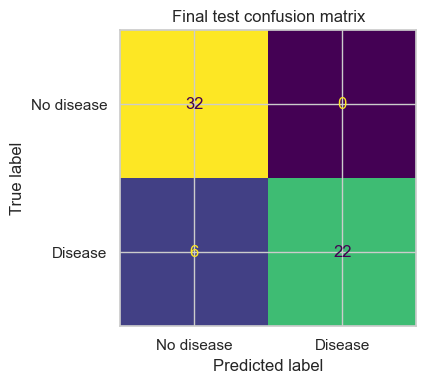

In [31]:
fig, ax = plot_confusion_matrix_from_scores(
    selected_eval["y_test"],
    selected_eval["y_test_score"],
    selected_eval["report_threshold"],
    title="Final test confusion matrix",
)
save_figure(fig, FIG_TEST / "final_test_confusion_matrix.png")
plt.show()


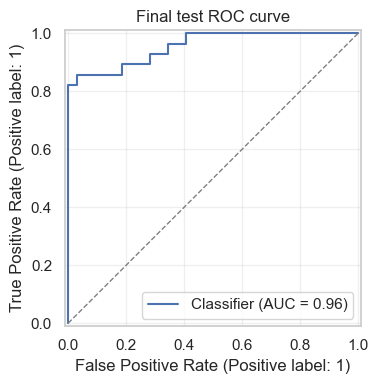

In [32]:
fig, ax = plot_roc_curve_from_scores(
    selected_eval["y_test"],
    selected_eval["y_test_score"],
    title="Final test ROC curve",
)
save_figure(fig, FIG_TEST / "final_test_roc_curve.png")
plt.show()


## Final Test Comparison by Clinical Stage

The same primary model is evaluated separately for each clinical stage. For each stage, the threshold is selected using only development predictions and then applied once to the locked test set.


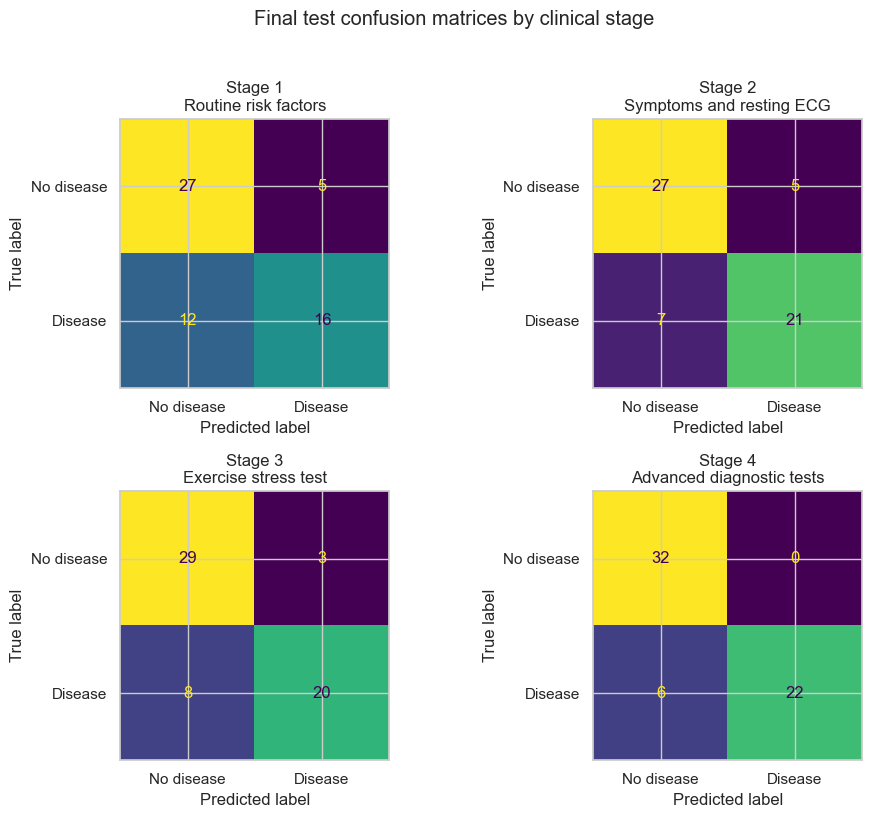

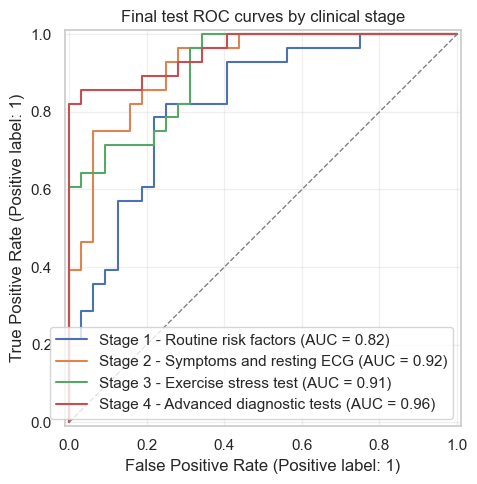

,stage,model,selected_threshold_from_development,roc_auc,roc_auc_ci_low,roc_auc_ci_high,sensitivity,specificity,precision,accuracy,balanced_accuracy,brier_score,tn,fp,fn,tp
0,Stage 1 - Routine risk factors,Logistic Regression,0.5,0.822545,0.703055,0.920016,0.571429,0.84375,0.761905,0.716667,0.707589,0.188331,27.0,5.0,12.0,16.0
1,Stage 2 - Symptoms and resting ECG,Logistic Regression,0.5,0.918527,0.841503,0.974897,0.750000,0.84375,0.807692,0.800000,0.796875,0.127430,27.0,5.0,7.0,21.0
2,Stage 3 - Exercise stress test,Logistic Regression,0.6,0.908482,0.826248,0.966528,0.714286,0.90625,0.869565,0.816667,0.810268,0.128600,29.0,3.0,8.0,20.0
3,Stage 4 - Advanced diagnostic tests,Logistic Regression,0.5,0.955357,0.900438,0.993326,0.785714,1.00000,1.000000,0.900000,0.892857,0.098049,32.0,0.0,6.0,22.0


In [33]:
primary_model_name = "Logistic Regression"
primary_spec = models[primary_model_name]

stage_threshold_results, stage_test_results, stage_score_rows = evaluate_stages_on_final_test(
    train_df=train_df,
    test_df=test_df,
    stage_features=STAGE_FEATURES,
    model_name=primary_model_name,
    model_spec=primary_spec,
    build_pipeline=build_pipeline,
    split_features_target=split_features_target,
    seed=SEED,
    threshold_grid=threshold_grid,
)

stage_threshold_results.to_csv(TAB_CV / "development_threshold_metrics_by_stage.csv", index=False)
stage_test_results.to_csv(TAB_TEST / "final_test_metrics_by_stage.csv", index=False)

fig_cm, fig_roc = save_final_stage_plots(stage_score_rows, FIG_TEST_CONFUSION, FIG_TEST_ROC, FIG_TEST)
plt.show()

final_metric_columns = [
    "stage", "model", "selected_threshold_from_development", "roc_auc",
    "roc_auc_ci_low", "roc_auc_ci_high", "sensitivity", "specificity",
    "precision", "accuracy", "balanced_accuracy", "brier_score",
    "tn", "fp", "fn", "tp",
]
stage_test_results[final_metric_columns]


## SHAP Explanation of the Final Model

SHAP is used only as an interpretability tool for the final fitted model. It helps inspect which transformed clinical variables push predictions toward heart disease or no heart disease. This is not causal evidence.


C:\SERGIO\3UNI\6_SEMESTRE\ai_for_medicine\Proyect_SP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


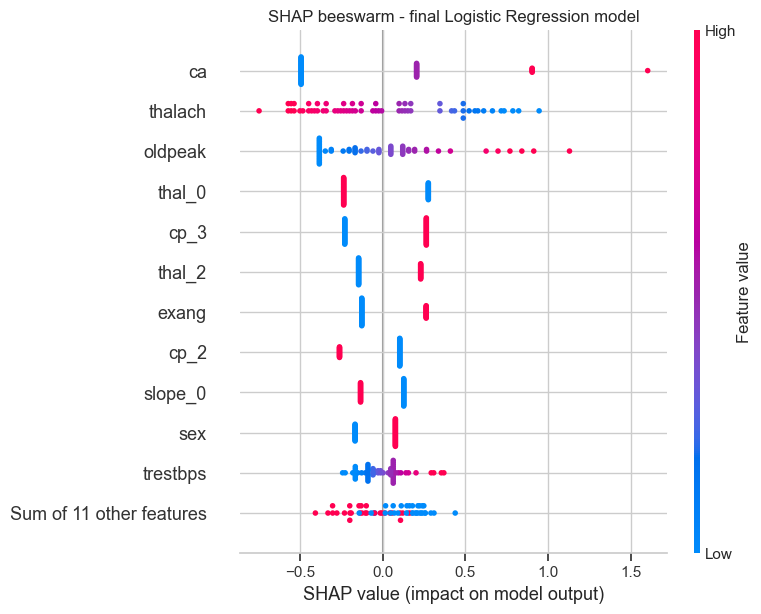

,feature,mean_abs_shap
5,ca,0.467730
3,thalach,0.372839
4,oldpeak,0.287777
19,thal_0,0.252144
12,cp_3,0.247519
21,thal_2,0.177174
8,exang,0.170639
11,cp_2,0.147460
16,slope_0,0.130046
6,sex,0.111193


In [34]:
# Explain the final fitted Logistic Regression model.
shap_importance = save_shap_beeswarm(
    pipeline=selected_eval["search"].best_estimator_,
    X_background=selected_eval["X_dev"],
    X_to_explain=selected_eval["X_test"],
    figure_path=FIG_EXPLAIN / "shap_beeswarm_final_model.png",
    table_path=TAB_EXPLAIN / "shap_feature_importance.csv",
)

plt.show()
shap_importance.head(12)


## Saved Outputs

The notebook saves the main figures and tables in `results/`. The full clinical discussion, limitations, ethics and references are written in the final report.


## References

**Cleveland Heart Disease Dataset**  
Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1989).  
Heart Disease [Dataset]. UCI Machine Learning Repository.  
https://doi.org/10.24432/C52P4X

**Lecture Notes – Artificial Intelligence for Medicine**  
Diciotti, S. (2025/2026).  
Lecture notes, Artificial Intelligence for Medicine / Machine Learning for Bioengineering. Università di Bologna.  
Course material used for project support on pipelines, nested cross-validation, data leakage, reproducibility, and medical AI methodology.

**Data Leakage and Reproducibility Crisis**  
Kapoor, S., & Narayanan, A. (2023).  
Leakage and the reproducibility crisis in machine-learning-based science. Patterns, 4(9), 100804.  
https://doi.org/10.1016/j.patter.2023.100804

**Cross-Validation and Small Sample Sizes**  
Varoquaux, G. (2018).  
Cross-validation failure: Small sample sizes lead to large error bars. NeuroImage, 180, 68–77.  
https://doi.org/10.1016/j.neuroimage.2017.06.061

**ROC Analysis**  
Fawcett, T. (2006).  
An introduction to ROC analysis. Pattern Recognition Letters, 27(8), 861–874.  
https://doi.org/10.1016/j.patrec.2005.10.010

**Synthetic Data in Medicine**  
Chen, R. J., Lu, M. Y., Chen, T. Y., Williamson, D. F. K., & Mahmood, F. (2021).  
Synthetic data in machine learning for medicine and healthcare. Nature Biomedical Engineering, 5, 493–497.  
https://doi.org/10.1038/s41551-021-00751-8

**Health Dataset Standards and Bias**  
Arora, A., Alderman, J. E., Palmer, J., Ganapathi, S., Laws, E., McCradden, M. D., et al. (2023).  
The value of standards for health datasets in artificial intelligence-based applications. Nature Medicine, 29(11), 2929–2938.  
https://doi.org/10.1038/s41591-023-02608-w

**MRI Features and Dementia Prediction**  
Marzi, C., Scheda, R., Salvadori, E., Giorgio, A., De Stefano, N., Poggesi, A., Inzitari, D., Pantoni, L., Mascalchi, M., & Diciotti, S. (2023).  
Fractal dimension of the cortical gray matter outweighs other brain MRI features as a predictor of transition to dementia in patients with mild cognitive impairment and leukoaraiosis. Frontiers in Human Neuroscience, 17, 1231513.  
https://doi.org/10.3389/fnhum.2023.1231513

**MRI Harmonization and Machine Learning Pipelines**  
Marzi, C., Giannelli, M., Barucci, A., Tessa, C., Mascalchi, M., & Diciotti, S. (2024).  
Efficacy of MRI data harmonization in the age of machine learning: A multicenter study across 36 datasets. Scientific Data, 11, 115.  
https://doi.org/10.1038/s41597-023-02421-7

**ChatGPT**  
OpenAI. (2026).  
ChatGPT [Large language model]. Used for project support, explanation, writing assistance, and code suggestions.  
https://chatgpt.com/

**Claude**  
Anthropic. (2026).  
Claude [Large language model]. Used for project support, explanation, writing assistance, and code suggestions.  
https://claude.ai/

**Google NotebookLM**  
Google. (2026).  
NotebookLM [Generative AI research and note-taking tool]. Used for document-based project support, summarization, and source organization.  
https://notebooklm.google.com/
